In [20]:
import numpy as np 
import pandas as pd
df = pd.read_excel("C:\\Users\\amarm\\Downloads\\glass.xlsx")
df

,Prepare a model for glass classification using Random Forest
0,Data Description:
1,RI : refractive index
2,Na: Sodium (unit measurement: weight percent i...
3,Mg: Magnesium
4,AI: Aluminum
5,Si: Silicon
6,K:Potassium
7,Ca: Calcium
8,Ba: Barium
9,Fe: Iron


In [21]:
df.head()

,Prepare a model for glass classification using Random Forest
0,Data Description:
1,RI : refractive index
2,Na: Sodium (unit measurement: weight percent i...
3,Mg: Magnesium
4,AI: Aluminum


In [12]:
ExcelTable = pd.ExcelFile("C:\\Users\\amarm\\Downloads\\glass.xlsx")
Context = pd.read_excel(ExcelTable, 'Description')
df = pd.read_excel(ExcelTable, 'glass')
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [13]:
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [40]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [41]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


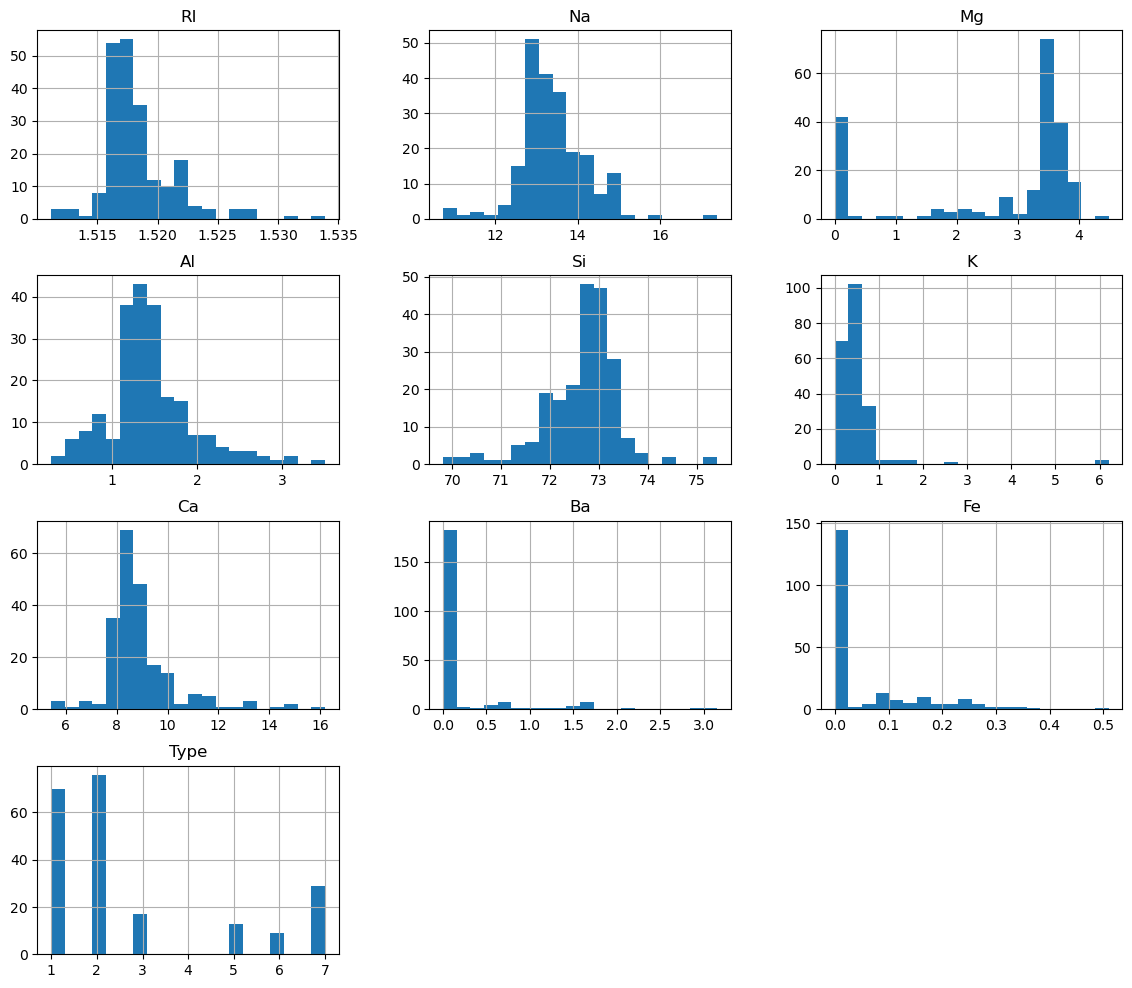

In [49]:
df.hist(figsize=(14,12), bins=20)
plt.show()

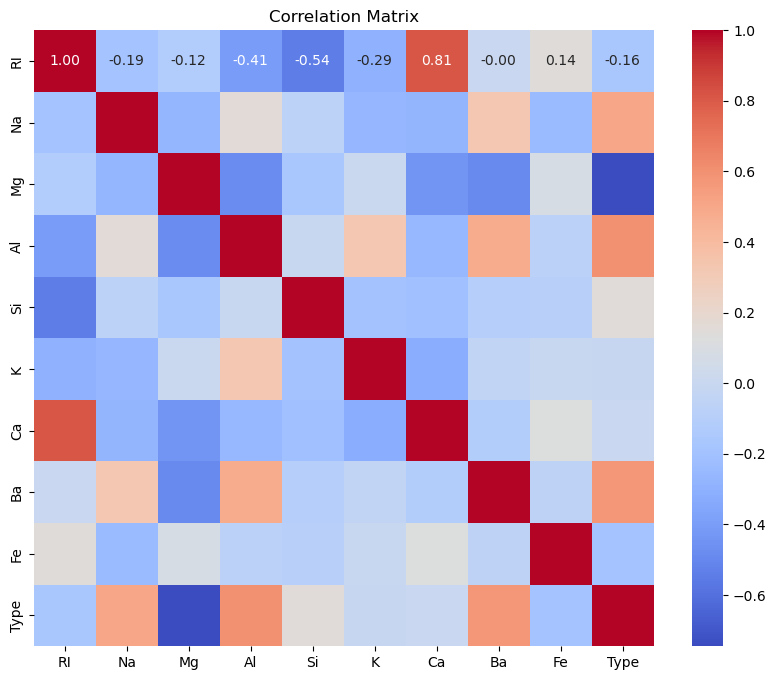

In [50]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [37]:
target_col = 'Type' 
if target_col not in df.columns:
    print(f"Error: Target column '{target_col}' not found. Available columns: {df.columns}")
    exit()
X = df.drop(target_col, axis=1)
y = df[target_col]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,0.872868,0.284953,1.254639,-0.692442,-1.127082,-0.671705,-0.145766,-0.352877,-0.586451
1,-0.249333,0.591817,0.636168,-0.170460,0.102319,-0.026213,-0.793734,-0.352877,-0.586451
2,-0.721318,0.149933,0.601422,0.190912,0.438787,-0.164533,-0.828949,-0.352877,-0.586451
3,-0.232831,-0.242853,0.698710,-0.310994,-0.052974,0.112107,-0.519052,-0.352877,-0.586451
4,-0.312045,-0.169205,0.650066,-0.411375,0.555256,0.081369,-0.624699,-0.352877,-0.586451
...,...,...,...,...,...,...,...,...,...
209,-0.704815,0.898681,-1.865511,2.881125,-0.052974,-0.640968,0.157088,1.783978,-0.586451
210,-0.500178,1.856097,-1.865511,1.094342,0.529374,-0.763919,-0.392276,2.852405,-0.586451
211,0.754046,1.168721,-1.865511,1.154570,0.995252,-0.763919,-0.364103,2.953200,-0.586451
212,-0.612399,1.193270,-1.865511,0.993960,1.241133,-0.763919,-0.335931,2.812087,-0.586451


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("\n--- Initial Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))


--- Initial Model Performance ---
Accuracy: 0.7209
              precision    recall  f1-score   support

           1       0.71      0.91      0.80        11
           2       0.64      0.50      0.56        14
           3       0.60      1.00      0.75         3
           5       0.50      0.25      0.33         4
           6       1.00      0.67      0.80         3
           7       0.89      1.00      0.94         8

    accuracy                           0.72        43
   macro avg       0.72      0.72      0.70        43
weighted avg       0.71      0.72      0.70        43



In [33]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("\n--- Best Hyperparameters ---")
print(grid_search.best_params_)

best_dt = grid_search.best_estimator_


--- Best Hyperparameters ---
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}



--- Tuned Model Performance ---
Accuracy: 0.7907
Confusion Matrix:
 [[10  0  0  0  1  0]
 [ 2  9  1  0  1  1]
 [ 1  1  1  0  0  0]
 [ 0  1  0  3  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  8]]


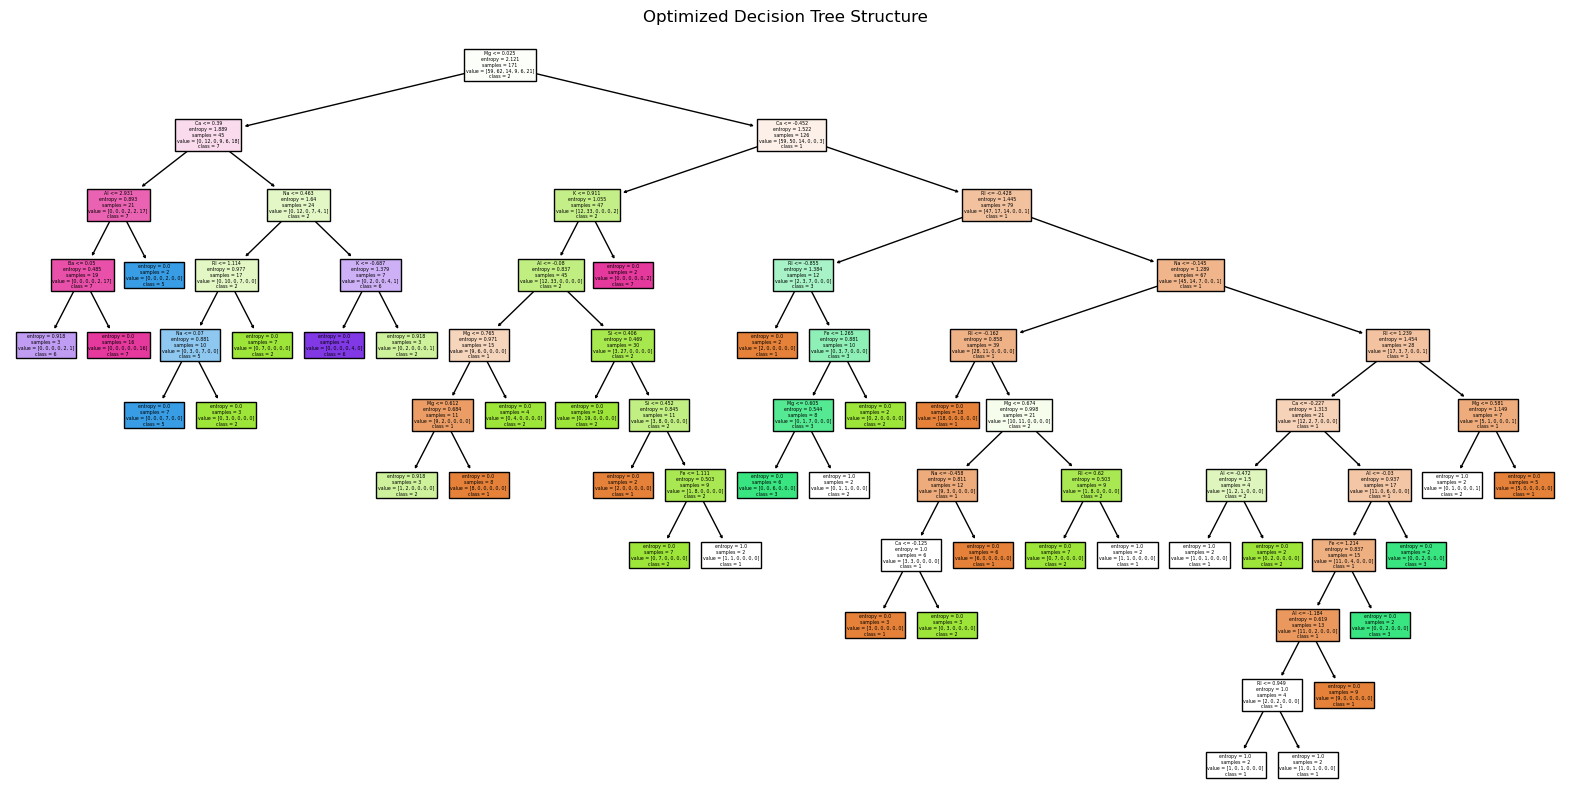

In [34]:
y_pred_best = best_dt.predict(X_test)
print("\n--- Tuned Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
plt.figure(figsize=(20, 10))
plot_tree(best_dt, feature_names=X.columns, filled=True, class_names=[str(c) for c in sorted(y.unique())])
plt.title("Optimized Decision Tree Structure")
plt.show()

In [95]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
y_pred_proba_gb = gb_model.predict_proba(X_test)[:, 1]
def evaluate_model(y_true, y_pred, y_proba, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"Accuracy: {accuracy:}")
    print("\n")
    return [accuracy]

In [96]:
rf_metrics = evaluate_model(y_test, y_pred_rf, y_pred_proba_rf, "Random Forest (Bagging)")
gb_metrics = evaluate_model(y_test, y_pred_gb, y_pred_proba_gb, "Gradient Boosting (Boosting)")
results_df = pd.DataFrame({
    'Metric': ['Accuracy'],
    'Random Forest': rf_metrics,
    'Gradient Boosting': gb_metrics
})
print("Comparison of Models:")
print(results_df)

--- Random Forest (Bagging) ---
Accuracy: 0.8372093023255814


--- Gradient Boosting (Boosting) ---
Accuracy: 0.8604651162790697


Comparison of Models:
     Metric  Random Forest  Gradient Boosting
0  Accuracy       0.837209           0.860465


In [ ]:
Differences between bagging and boosting
->Trains multiple models independently and in parallel on random subsets of data.
->Trains models sequentially. Each new model corrects the errors of the previous one.
Resampling:
Undersampling: Reduce the majority class (risk of losing data).
Oversampling: Duplicate the minority class (risk of overfitting).
Synthetic Data (SMOTE): Generates new, artificial examples for the minority class instead of just copying them.
Better Metrics: Don't use Accuracy, Use Precision, Recall, F1-Score, and ROC-AUC for better clarity